<a href="https://colab.research.google.com/github/arpittyagi2/python_learning/blob/main/Day3_assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


In [3]:
# ==============================================================================
# STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING
# ==============================================================================
"""
BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:
┌────────────────────┐     ┌────────────────────┐     ┌────────────────────┐
│ Stage 1: Context   │ ──> │ Stage 2: Profiling │ ──> │ Stage 3: Univariate│
└────────────────────┘     └────────────────────┘     └────────────────────┘
                                                                 │
┌────────────────────┐     ┌────────────────────┐     ┌──────────┴─────────┐
│ Stage 6: Insights  │ <── │ Stage 5: Multivar  │ <── │ Stage 4: Bivariate │
└────────────────────┘     └────────────────────┘     └────────────────────┘
"""
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [4]:
# ==============================================================================
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT
# ==============================================================================
print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---")
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))

print("\n--- 4. Categorical Cardinality & Balance ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_2532/278002177.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])


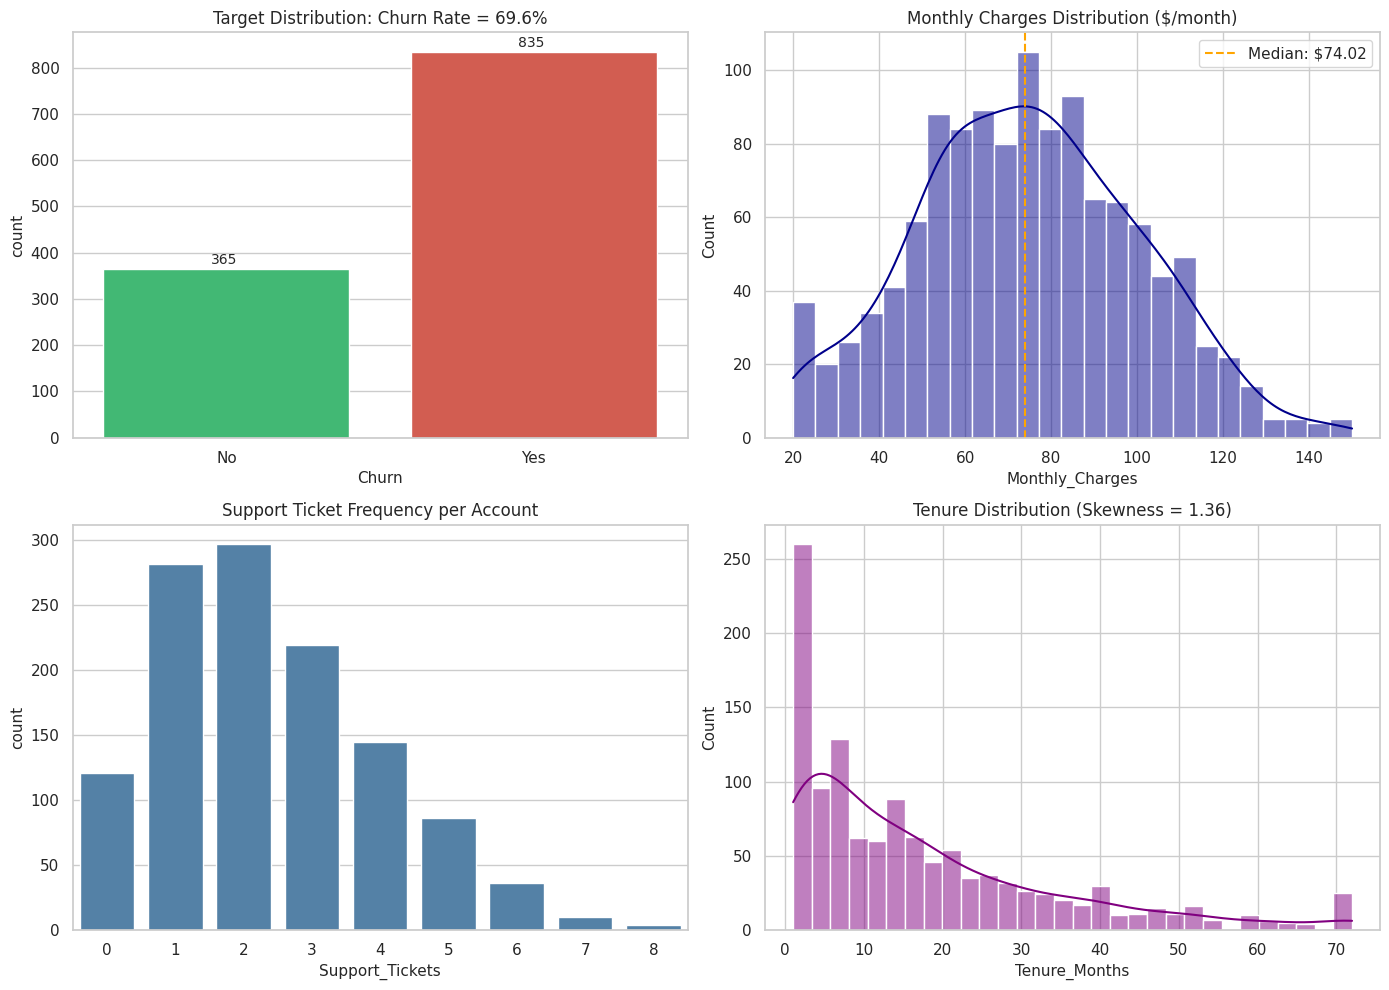

In [5]:
# ==============================================================================
# STAGE 3: UNIVARIATE ANALYSIS
# ==============================================================================
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30)
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()

# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

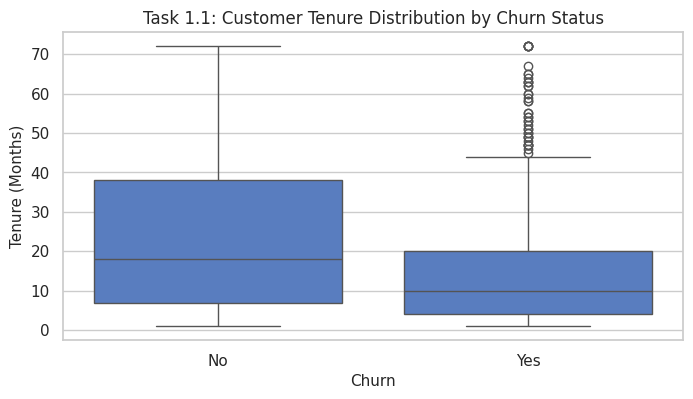

--- Median and IQR of Tenure ---


,Median,Q1,Q3,IQR
Churn,,,,
No,18.0,7.0,38.0,31.0
Yes,10.0,4.0,20.0,16.0


--- Churn Rates across Contract & Tech Support ---


Churn                           No    Yes
Contract_Type  Tech_Support              
Month-to-Month No            13.86  86.14
               No internet   15.18  84.82
               Yes           15.29  84.71
One-Year       No            31.88  68.12
               No internet   40.48  59.52
               Yes           48.12  51.88
Two-Year       No            63.55  36.45
               No internet   54.05  45.95
               Yes           65.12  34.88

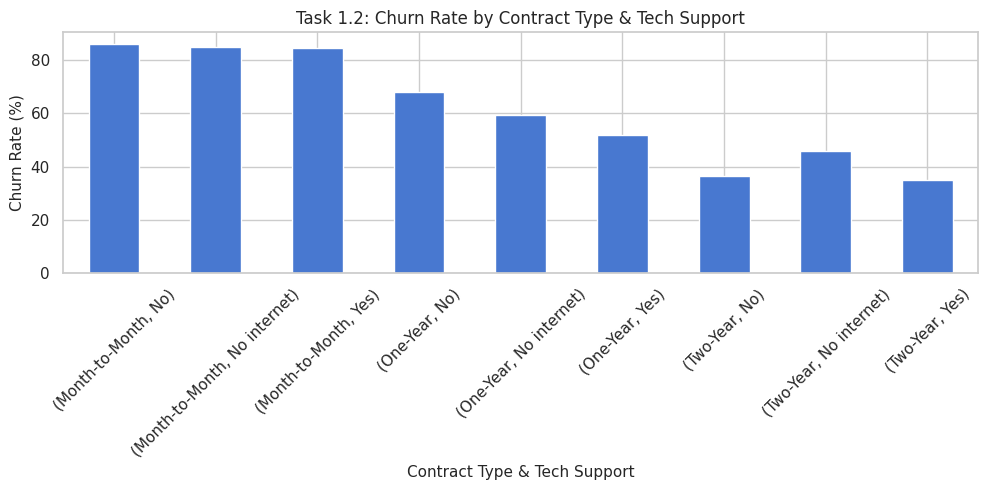

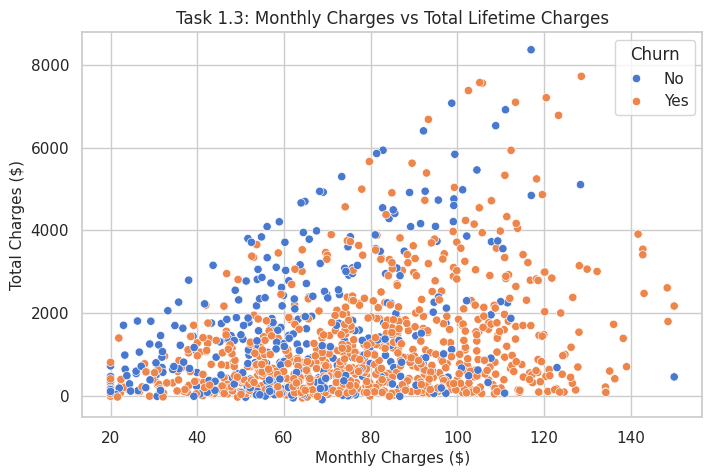

Pearson Correlation: 0.300
Spearman Correlation: 0.269


In [6]:
# ==============================================================================
# TASK 1: BIVARIATE ANALYSIS (3 Sub-Tasks)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x='Churn', y='Tenure_Months')
plt.title("Task 1.1: Customer Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

# Compute Median and IQR
tenure_stats = df.groupby('Churn')['Tenure_Months'].agg(
    Median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

tenure_stats['IQR'] = tenure_stats['Q3'] - tenure_stats['Q1']

print("--- Median and IQR of Tenure ---")
display(tenure_stats.round(2))


# ------------------------------------------------------------------------------
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# ------------------------------------------------------------------------------

# Calculate churn percentage for each Contract Type and Tech Support combination
contract_tech_churn = pd.crosstab(
    [df['Contract_Type'], df['Tech_Support']],
    df['Churn'],
    normalize='index'
) * 100

print("--- Churn Rates across Contract & Tech Support ---")
display(contract_tech_churn.round(2))

# Plot churn rates
contract_tech_churn['Yes'].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
plt.xlabel("Contract Type & Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Monthly_Charges',
    y='Total_Charges',
    hue='Churn'
)

plt.title("Task 1.3: Monthly Charges vs Total Lifetime Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Total Charges ($)")
plt.show()

# Remove missing values before calculating correlations
data = df[['Monthly_Charges', 'Total_Charges']].dropna()

pearson_corr = data['Monthly_Charges'].corr(data['Total_Charges'], method='pearson')
spearman_corr = data['Monthly_Charges'].corr(data['Total_Charges'], method='spearman')

print(f"Pearson Correlation: {pearson_corr:.3f}")
print(f"Spearman Correlation: {spearman_corr:.3f}")

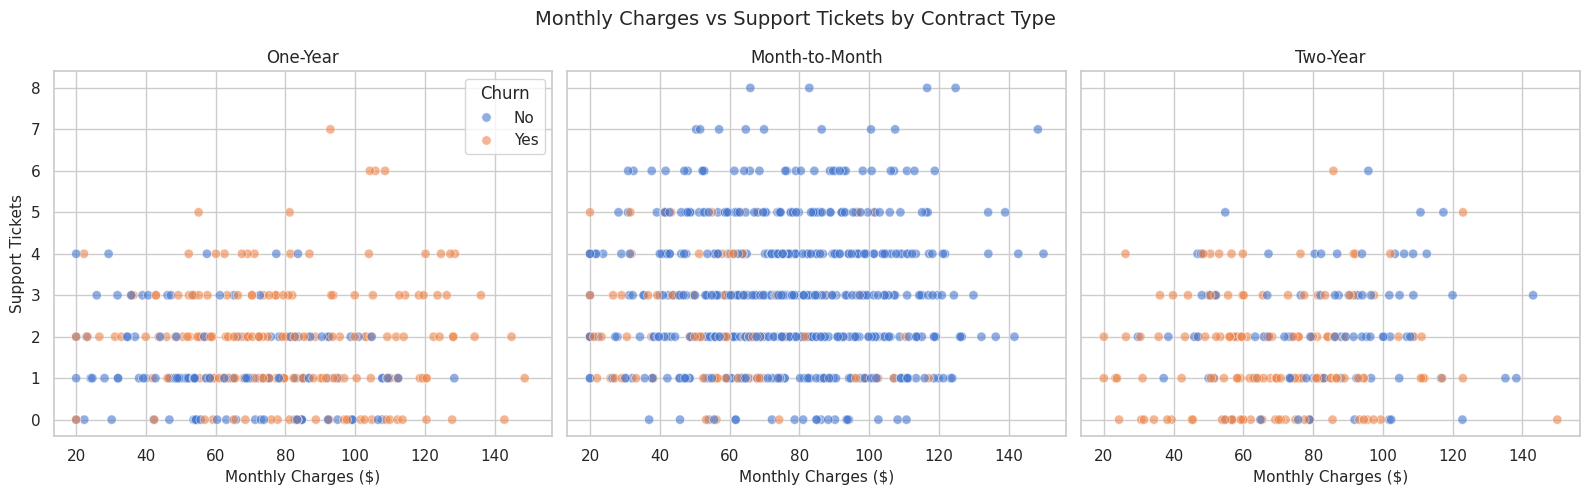

In [7]:
# ------------------------------------------------------------------------------
# 2.2 MULTI-DIMENSIONAL SEGMENTATION
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

contracts = df['Contract_Type'].unique()

for ax, contract in zip(axes, contracts):
    data = df[df['Contract_Type'] == contract]

    sns.scatterplot(
        data=data,
        x='Monthly_Charges',
        y='Support_Tickets',
        hue='Churn',
        alpha=0.6,
        s=45,
        ax=ax
    )

    ax.set_title(contract)
    ax.set_xlabel("Monthly Charges ($)")
    ax.set_ylabel("Support Tickets")

# Keep only one legend
axes[1].get_legend().remove()
axes[2].get_legend().remove()

plt.suptitle("Monthly Charges vs Support Tickets by Contract Type", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT
# ==============================================================================

# ------------------------------------------------------------------------------
# 3.1 Missing Value Treatment in Total_Charges
# ------------------------------------------------------------------------------

# Calculate Total Charges using tenure and monthly charges
# This is better than mean/median because it uses each customer's actual data.
df['Total_Charges'] = df['Total_Charges'].fillna(
    df['Tenure_Months'] * df['Monthly_Charges']
)

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")


# ------------------------------------------------------------------------------
# 3.2 Outlier Investigation: Support Tickets
# ------------------------------------------------------------------------------

q1_tix = df['Support_Tickets'].quantile(0.25)
q3_tix = df['Support_Tickets'].quantile(0.75)
iqr_tix = q3_tix - q1_tix

upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df['Support_Tickets'] > upper_fence]

print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
print(f"Churn Rate in Outlier Accounts: {(outlier_accounts['Churn'] == 'Yes').mean() * 100:.2f}%")

Missing values remaining in Total_Charges: 0
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [9]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================

# Feature 1: Ticket velocity
df['Ticket_Velocity'] = df['Support_Tickets'] / (df['Tenure_Months'] + 1)

# Feature 2: High-risk customer flag
df['High_Risk_Flag'] = (
    (df['Contract_Type'] == 'Month-to-Month') &
    (df['Tech_Support'] == 'No')
).astype(int)

# Compare churn rates
print("--- Churn Rate Comparison for Engineered Features ---")

display(
    df.groupby('High_Risk_Flag')['Churn']
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .round(2)
)

# Compare ticket velocity between churned and retained customers
display(
    df.groupby('Churn')['Ticket_Velocity']
      .describe()
      .round(2)
)

--- Churn Rate Comparison for Engineered Features ---


Churn,No,Yes
High_Risk_Flag,,
0,36.01,63.99
1,13.86,86.14


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.17,0.28,0.0,0.02,0.07,0.18,2.0
Yes,835.0,0.42,0.53,0.0,0.09,0.20,0.50,3.0


In [10]:
# ==============================================================================
# STRATEGIC INSIGHTS
# ==============================================================================

"""
### 📊 Strategic Insight 1: Month-to-Month Contracts Are the Core Churn Driver

Claim:
Contract length is the single strongest churn lever — Month-to-Month customers
churn at roughly 2–2.5x the rate of Two-Year customers, regardless of tech
support status.

Evidence:
Churn rate by Contract Type x Tech Support: Month-to-Month = 84.71%-86.14%
across all tech-support tiers, vs. Two-Year = 34.88%-45.95% and
One-Year = 51.88%-68.12% (n=1,200).

Business Action:
Launch a targeted contract-conversion campaign (discounted pricing or bundled
perks) aimed specifically at Month-to-Month accounts to migrate them to
One-Year or Two-Year terms.
"""


"""
### 📊 Strategic Insight 2: Early-Tenure Accounts Churn Fastest and Leave Sooner

Claim:
Customers who churn do so significantly earlier in their lifecycle than those
who stay, and the timing is far less predictable for churners.

Evidence:
Median tenure: Churned = 10 months (IQR 4-20, IQR width=16) vs.
Retained = 18 months (IQR 7-38, IQR width=31).

Business Action:
Front-load Customer Success touchpoints into the first 10 months — structured
onboarding, 30/60/90-day check-ins, and proactive value reviews before the
highest-risk window closes.
"""


"""
### 📊 Strategic Insight 3: Support Ticket Outliers Are a Near-Certain Churn Signal

Claim:
Accounts with abnormally high support ticket volume are essentially
guaranteed to churn.

Evidence:
Using the IQR outlier fence (Q1=1, Q3=3, IQR=2 -> upper fence=6 tickets),
14 accounts were flagged as outliers, and 100.00% of them churned.

Business Action:
Build an automated alert that flags any account crossing 6+ support tickets
and routes it immediately to a senior success manager for a retention
intervention call.
"""


"""
### 📊 Strategic Insight 4: The "High-Risk" Segment Confirms Compounding Risk

Claim:
Customers who are both on a Month-to-Month plan and lack technical support
churn substantially more than the rest of the base.

Evidence:
High_Risk_Flag=1 (Month-to-Month & No Tech Support) churns at 86.14% vs.
63.99% for High_Risk_Flag=0 — a 22.15 percentage-point gap.

Business Action:
Bundle a free/discounted tech-support tier into retention offers made to
Month-to-Month customers as a low-cost lever to pull them out of the
highest-risk segment.
"""


"""
### 📊 Strategic Insight 5: Ticket Velocity Separates Churners From Retained Customers

Claim:
It's not just ticket volume but the rate of ticket generation relative to
tenure that distinguishes churners.

Evidence:
Mean Ticket_Velocity: Churned = 0.42 (median 0.20, 75th pct 0.50, n=835) vs.
Retained = 0.17 (median 0.07, 75th pct 0.18, n=365) — churners generate
tickets at roughly 2.5x the rate of retained customers.

Business Action:
Add Ticket_Velocity as a real-time health-score input in the CS dashboard so
reps can prioritize accounts whose ticket rate is accelerating, not just
those with high raw ticket counts.
"""

"\n### 📊 Strategic Insight 5: Ticket Velocity Separates Churners From Retained Customers\n\nClaim:\nIt's not just ticket volume but the rate of ticket generation relative to\ntenure that distinguishes churners.\n\nEvidence:\nMean Ticket_Velocity: Churned = 0.42 (median 0.20, 75th pct 0.50, n=835) vs.\nRetained = 0.17 (median 0.07, 75th pct 0.18, n=365) — churners generate\ntickets at roughly 2.5x the rate of retained customers.\n\nBusiness Action:\nAdd Ticket_Velocity as a real-time health-score input in the CS dashboard so\nreps can prioritize accounts whose ticket rate is accelerating, not just\nthose with high raw ticket counts.\n"

In [11]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""

'\nCOMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:\n\n1. Download your completed notebook from Colab:\n   File -> Download -> Download .ipynb\n\n2. Move the file into your local portfolio Git repository:\n   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/\n\n3. Commit and push to GitHub:\n   $ cd ~/projects/data-science-portfolio/\n   $ git add EDA_Customer_Churn_Portfolio.ipynb\n   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"\n   $ git push origin main\n\n4. Ensure your GitHub README includes:\n   - Executive Summary (Top 3 Findings)\n   - Methodology & Visualizations\n   - Recommended Strategic Interventions\n'